In [1]:
from lsst.daf.butler import Butler
from lsst.geom import Point2D, Extent2I
from lsst.pipe.tasks.peekExposure import PeekExposureTask
import lsst.analysis.tools.actions.plot as lsstplot
import lsst.afw.display as afwDisplay
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib ipympl

In [2]:
# Set a standard figure size to use
plt.rcParams['figure.figsize'] = (8.0, 8.0)

In [3]:
nbutler = Butler(
    "/repo/embargo",
    instrument="LSSTCam",
    collections="LSSTCam/runs/nightlyValidation",
)

In [4]:
registry = nbutler.registry
for col in registry.queryCollections():
    if "LSSTCam/run" in col:
        print(col)

LSSTCam/runs/nightlyValidation/20250418/w_2025_16/DM-50157/20250419T111324Z
LSSTCam/runs/quickLookTesting/47
LSSTCam/runs/quickLookTesting/18
LSSTCam/runs/nightlyValidation/20250423/w_2025_17/DM-50157/hips/20250426T165153Z
LSSTCam/runs/DRP/20250420_20250429/w_2025_18/DM-50628/20250502T071557Z
LSSTCam/runs/DRP/20250420_20250429/w_2025_18/DM-50628/20250503T060652Z
LSSTCam/runs/nightlyValidation/20250419/d_2025_04_19/DM-50157/hips/deep_coadd/20250421T161206Z
LSSTCam/runs/quickLookTesting/26
LSSTCam/runs/DRP/20250420_20250429/w_2025_18/DM-50628/20250502T091316Z
LSSTCam/runs/DRP/FL/w_2025_19/DM-50795/20250510T044948Z
LSSTCam/runs/nightlyValidation/20250420/d_2025_04_19/DM-50157/20250422T041005Z
LSSTCam/runs/quickLookTesting/83
LSSTCam/runs/quickLookTesting/27
LSSTCam/runs/nightlyValidation/20250419/d_2025_04_19/DM-50157/hips/deep_coadd/20250421T172552Z
LSSTCam/runs/nightlyValidation/20250418/w_2025_16/DM-50157/20250419T134227Z
LSSTCam/runs/nightlyValidation/20250419/d_2025_04_19/DM-50157/hi

In [5]:
for ref in registry.queryDatasets(
    'post_isr_image',
    instrument='LSSTCam',
    day_obs=20250417,
    # exposure=2025041600581,
    detector=94
):
    print(ref.dataId)

{instrument: 'LSSTCam', detector: 94, exposure: 2025041700470, band: 'i', day_obs: 20250417, group: '2025-04-17T23:58:47.803', physical_filter: 'i_39'}
{instrument: 'LSSTCam', detector: 94, exposure: 2025041700472, band: 'i', day_obs: 20250417, group: '2025-04-17T23:58:47.803', physical_filter: 'i_39'}
{instrument: 'LSSTCam', detector: 94, exposure: 2025041700474, band: 'i', day_obs: 20250417, group: '2025-04-17T23:58:47.803', physical_filter: 'i_39'}
{instrument: 'LSSTCam', detector: 94, exposure: 2025041700476, band: 'i', day_obs: 20250417, group: '2025-04-18T00:03:23.112', physical_filter: 'i_39'}
{instrument: 'LSSTCam', detector: 94, exposure: 2025041700478, band: 'i', day_obs: 20250417, group: '2025-04-18T00:03:23.112', physical_filter: 'i_39'}
{instrument: 'LSSTCam', detector: 94, exposure: 2025041700481, band: 'i', day_obs: 20250417, group: '2025-04-18T00:03:23.112#4', physical_filter: 'i_39'}
{instrument: 'LSSTCam', detector: 94, exposure: 2025041700484, band: 'i', day_obs: 202

In [10]:
def plot_detector(butler, dataid, fig, axs):

    fig.suptitle(f"{dataid['exposure']}, det: {dataid['detector']}")
    
    ax = axs[0]
    img = butler.get("raw", dataId=dataid)
    img.getImage()
    i = ax.imshow(
        img.image.array,
        origin='lower',
        vmin=np.percentile(img.image.array, 10),
        vmax=np.percentile(img.image.array, 90)
    )
    fig.colorbar(i, ax=ax)
    ax.set_title("raw")

    # ax = axs[1]
    # img = butler.get("post_isr_image", dataId=dataid)
    # img.getImage()
    # i = ax.imshow(
    #     img.image.array,
    #     origin='lower',
    #     vmin=np.percentile(img.image.array, 10),
    #     vmax=np.percentile(img.image.array, 90)
    # )
    # ax.set_title("post_isr")
    # fig.colorbar(i, ax=ax)

    # ax = axs[2]
    # img = butler.get("preliminary_visit_image", dataId=dataid)
    # img.getImage()
    # i = ax.imshow(
    #     img.image.array,
    #     origin='lower',
    #     vmin=np.percentile(img.image.array, 10),
    #     vmax=np.percentile(img.image.array, 90)
    # )
    # ax.set_title("preliminary_visit")
    # fig.colorbar(i, ax=ax)
    # plt.tight_layout()

    del img

In [13]:
expnum = 490
dataid = {'exposure': 2025041700000+expnum, "detector": 94, 'visit': 2025041700000+expnum}

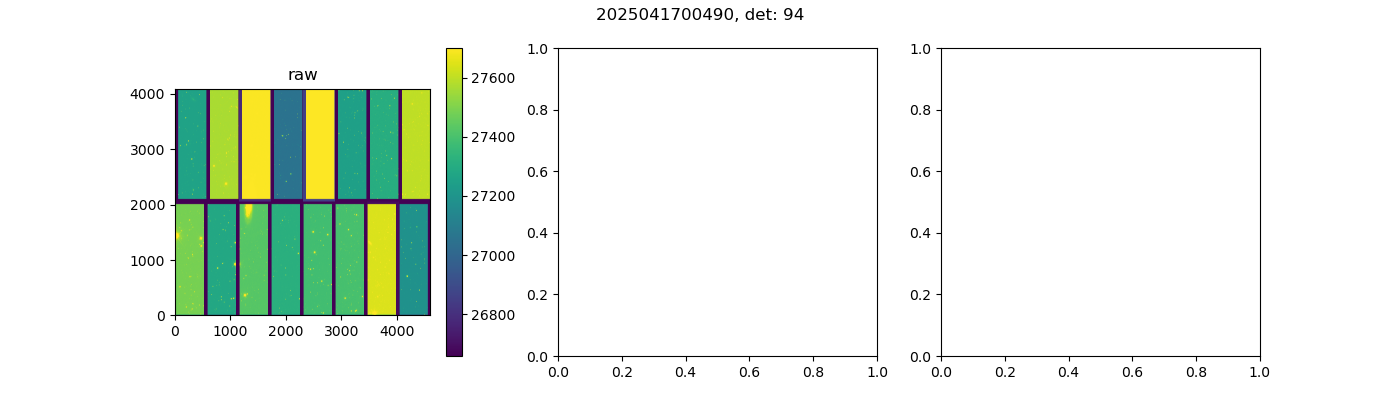

In [14]:
fig, ax = plt.subplots(1,3, figsize=(14, 4))

plot_detector(nbutler, dataid, fig, ax)

In [20]:
afwDisplay.setDefaultBackend("firefly")
display = afwDisplay.Display(dims=(1000, 600))
img = nbutler.get("preliminary_visit_image", dataId=dataid)
display.mtv(img)

In [107]:
registry.queryDatasetTypes()

[DatasetType('raw', {band, instrument, day_obs, detector, group, physical_filter, exposure}, Exposure),
 DatasetType('uw_stars_20240228', {htm7}, SimpleCatalog),
 DatasetType('atlas_refcat2_20220201', {htm7}, SimpleCatalog),
 DatasetType('gaia_dr3_20230707', {htm7}, SimpleCatalog),
 DatasetType('bias', {instrument, detector}, ExposureF, isCalibration=True),
 DatasetType('camera', {instrument}, Camera, isCalibration=True),
 DatasetType('crosstalk', {instrument, detector}, CrosstalkCalib, isCalibration=True),
 DatasetType('dark', {instrument, detector}, ExposureF, isCalibration=True),
 DatasetType('defects', {instrument, detector}, Defects, isCalibration=True),
 DatasetType('flat', {band, instrument, detector, physical_filter}, ExposureF, isCalibration=True),
 DatasetType('goodSeeingCoadd', {band, skymap, tract, patch}, ExposureF),
 DatasetType('pretrainedModelPackage', {}, NNModelPackagePayload),
 DatasetType('skyMap', {skymap}, SkyMap),
 DatasetType('transmission_filter', {band, instru

In [108]:
registry.queryDatasetTypes('finalized_src_table')

[DatasetType('finalized_src_table', {band, instrument, day_obs, physical_filter, visit}, DataFrame)]

In [110]:
list(registry.queryDatasets('finalized_src_table'))

[]

In [111]:
list(registry.queryDatasets('src'))

[]

In [118]:
len(list(registry.queryDatasets('preliminary_visit_image', day_obs=20250415)))

23160

In [113]:
print(registry.queryDatasetTypes('refit_psf_star'))
print(len(list(registry.queryDatasets('refit_psf_star'))))

[DatasetType('refit_psf_star', {band, instrument, day_obs, physical_filter, visit}, ArrowAstropy)]
0


me no understand...

edit: me understand. Piff not run yet!